In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 120
sns.set_style("whitegrid")

import sys
sys.path.append('../src')
from config import CITY_NAME, LAT, LON, BBOX
import os, datetime, requests, pandas as pd
from PIL import Image
from io import BytesIO
from IPython.display import display

print(f"City: {CITY_NAME} {LAT},{LON}")
print(f"BBOX: {BBOX}")

City: Chhatrapati Sambhajinagar 19.8762,75.3433
BBOX: {'lat_min': 19.3, 'lat_max': 20.4, 'lon_min': 74.8, 'lon_max': 75.9}


In [14]:
sd = (datetime.date.today() - datetime.timedelta(days=60)).isoformat()
ed = datetime.date.today().isoformat()
url = f"https://archive-api.open-meteo.com/v1/archive?latitude={LAT}&longitude={LON}&start_date={sd}&end_date={ed}&hourly=temperature_2m,relative_humidity_2m,precipitation,cloud_cover&timezone=Asia/Kolkata"

r = requests.get(url, timeout=30).json()
df = pd.DataFrame(r['hourly'])
df.rename(columns={'time':'timestamp','temperature_2m':'temperature','relative_humidity_2m':'humidity'}, inplace=True)

def label_row(row):
    if row['precipitation'] > 1.0: return "Heavy Rain"
    elif row['precipitation'] > 0.1: return "Light Rain"
    elif row['cloud_cover'] > 70: return "Cloudy"
    else: return "Clear"

df['condition'] = df.apply(label_row, axis=1)
os.makedirs("../data/processed", exist_ok=True)
df.to_csv("../data/processed/labels.csv", index=False)

# Styled table in Times New Roman
styled = df.head(10).style.set_table_styles([
    {'selector':'th','props':[('font-family','Times New Roman'),('background-color','#1f77b4'),('color','white'),('font-size','12pt')]},
    {'selector':'td','props':[('font-family','Times New Roman'),('font-size','11pt')]}
]).background_gradient(subset=['temperature'], cmap='coolwarm')

display(styled)
print(f"Total Rows: {len(df)}")

,timestamp,temperature,humidity,precipitation,cloud_cover,condition
0,2026-05-27T00:00,29.700000,62,0.000000,24,Clear
1,2026-05-27T01:00,29.200000,64,0.000000,27,Clear
2,2026-05-27T02:00,28.300000,70,0.000000,9,Clear
3,2026-05-27T03:00,27.300000,76,0.000000,2,Clear
4,2026-05-27T04:00,26.400000,78,0.000000,13,Clear
5,2026-05-27T05:00,25.800000,84,0.000000,5,Clear
6,2026-05-27T06:00,25.900000,82,0.000000,5,Clear
7,2026-05-27T07:00,27.200000,74,0.000000,2,Clear
8,2026-05-27T08:00,29.400000,61,0.000000,3,Clear
9,2026-05-27T09:00,31.900000,50,0.000000,30,Clear


Total Rows: 1464


https://wvs.earthdata.nasa.gov/api/v1/snapshot?REQUEST=GetSnapshot&TIME=2026-07-26T14:00:00Z&BBOX=74.8,19.3,75.9,20.4&CRS=EPSG:4326&LAYERS=Himawari_AHI_Band13_Clean_Infrared&FORMAT=image/png&WIDTH=800&HEIGHT=800


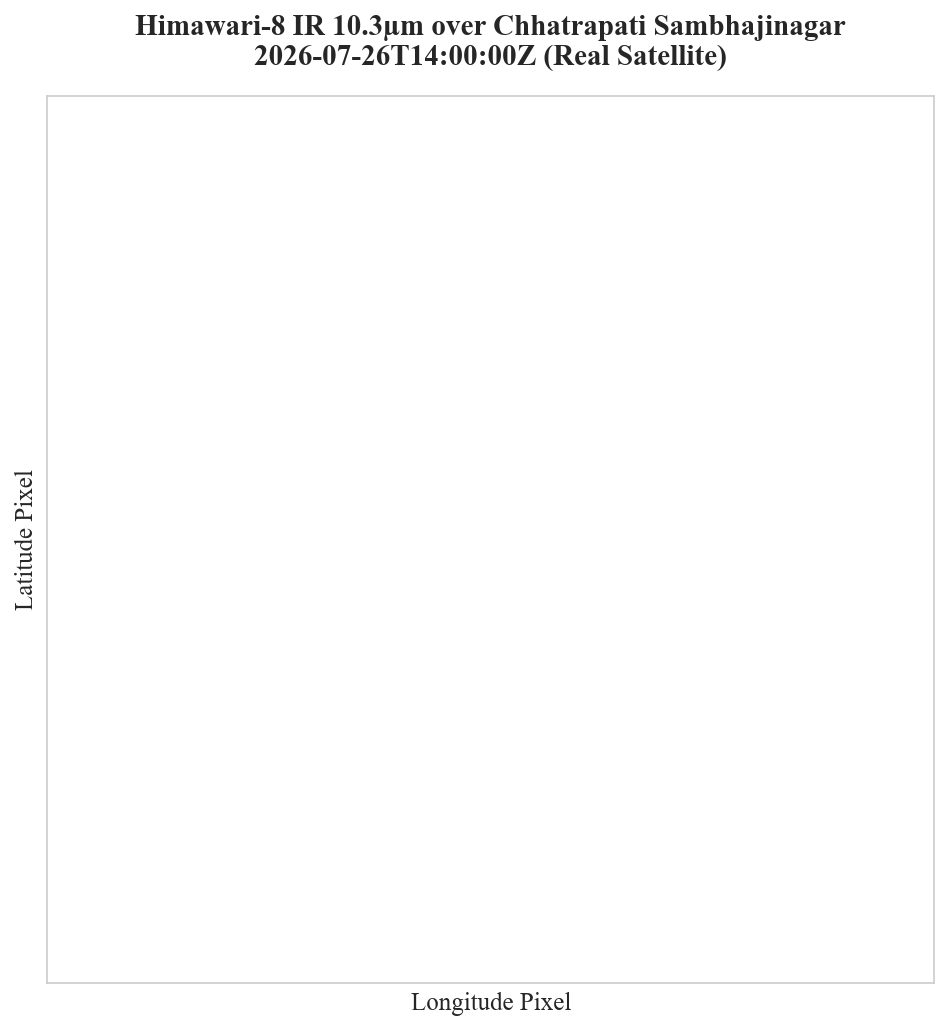

2561

In [15]:
bbox_str = f"{BBOX['lon_min']},{BBOX['lat_min']},{BBOX['lon_max']},{BBOX['lat_max']}"
time_str = (datetime.datetime.utcnow() - datetime.timedelta(hours=1)).strftime("%Y-%m-%dT%H:00:00Z")
sat_url = f"https://wvs.earthdata.nasa.gov/api/v1/snapshot?REQUEST=GetSnapshot&TIME={time_str}&BBOX={bbox_str}&CRS=EPSG:4326&LAYERS=Himawari_AHI_Band13_Clean_Infrared&FORMAT=image/png&WIDTH=800&HEIGHT=800"

print(sat_url)
resp = requests.get(sat_url, timeout=20)
img = Image.open(BytesIO(resp.content))

fig, ax = plt.subplots(figsize=(7,7), dpi=150)
ax.imshow(img, cmap='gray')
ax.set_title(f"Himawari-8 IR 10.3µm over {CITY_NAME}\n{time_str} (Real Satellite)", fontname='Times New Roman', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Longitude Pixel", fontname='Times New Roman')
ax.set_ylabel("Latitude Pixel", fontname='Times New Roman')
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

os.makedirs("../data/raw", exist_ok=True)
open(f"../data/raw/sat_{datetime.datetime.now().strftime('%Y%m%d_%H')}.png",'wb').write(resp.content)

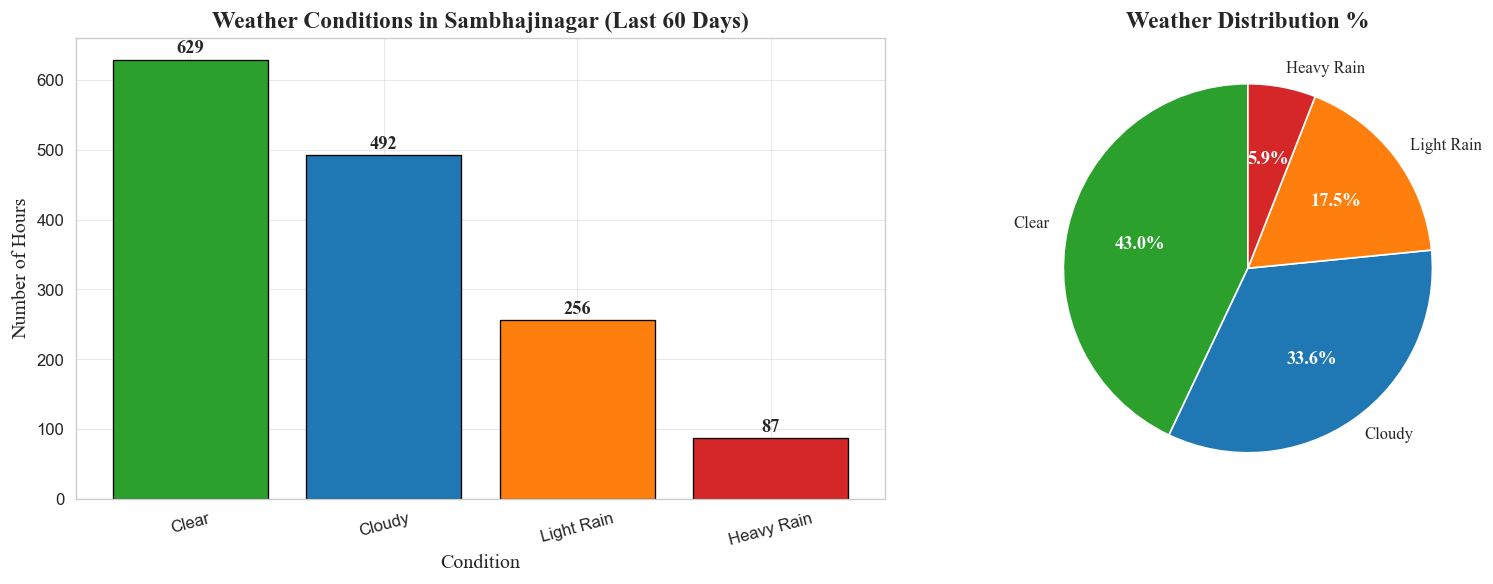

,Condition,Hours,Percentage
0,Clear,629,43.0%
1,Cloudy,492,33.6%
2,Light Rain,256,17.5%
3,Heavy Rain,87,5.9%


In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

count_data = df['condition'].value_counts()
bar_colors = ["#2ca02c" if x=="Clear" else "#1f77b4" if x=="Cloudy" else "#ff7f0e" if x=="Light Rain" else "#d62728" for x in count_data.index]

ax1.bar(count_data.index, count_data.values, color=bar_colors, edgecolor='black', linewidth=0.8)
ax1.set_title("Weather Conditions in Sambhajinagar (Last 60 Days)", fontname='Times New Roman', fontweight='bold')
ax1.set_xlabel("Condition", fontname='Times New Roman')
ax1.set_ylabel("Number of Hours", fontname='Times New Roman')
ax1.tick_params(axis='x', rotation=15)
for i, v in enumerate(count_data.values):
    ax1.text(i, v+10, str(v), ha='center', fontname='Times New Roman', fontweight='bold')

wedges, texts, autotexts = ax2.pie(count_data.values, labels=count_data.index, autopct='%1.1f%%', colors=bar_colors, startangle=90, textprops={'fontname':'Times New Roman'})
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontname('Times New Roman')
ax2.set_title("Weather Distribution %", fontname='Times New Roman', fontweight='bold')

plt.tight_layout()
plt.show()

# Table
summary = df['condition'].value_counts().reset_index()
summary.columns = ['Condition', 'Hours']
summary['Percentage'] = (summary['Hours']/len(df)*100).round(2)
display(summary.style.set_table_styles([
    {'selector':'th','props':[('font-family','Times New Roman'),('background-color','#2ca02c'),('color','white')]},
    {'selector':'td','props':[('font-family','Times New Roman')]}
]).format({'Percentage':"{:.1f}%"}))

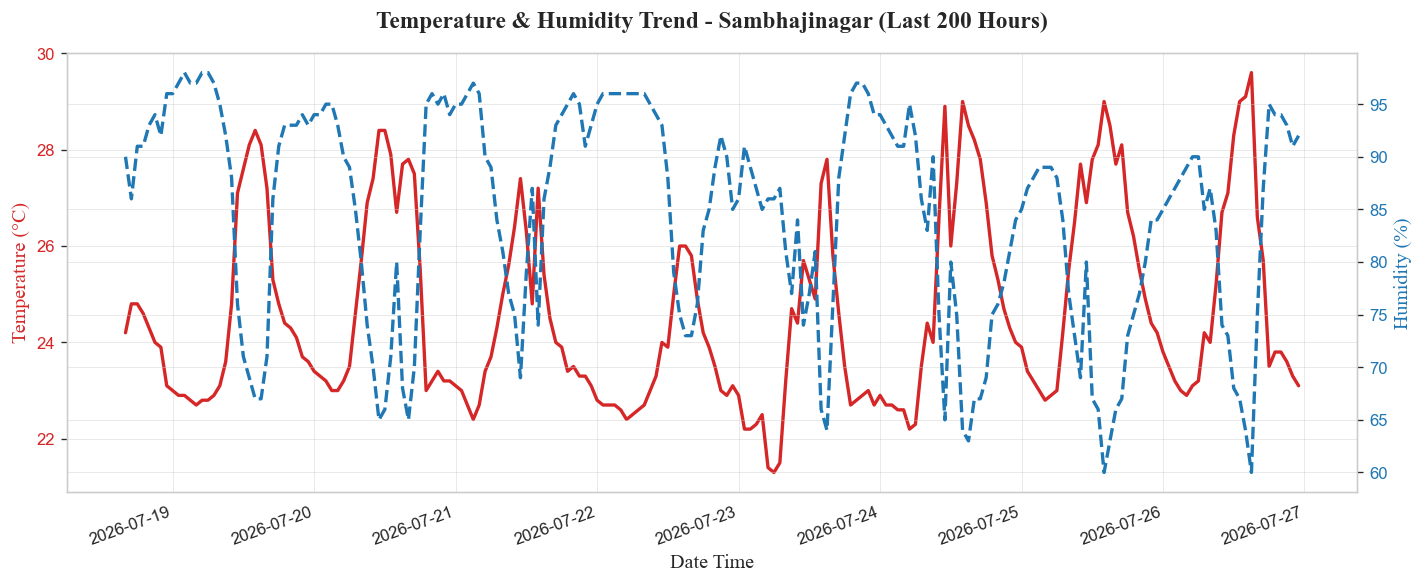

In [17]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(df['timestamp'].tail(200), df['temperature'].tail(200), color='#d62728', linewidth=2, label='Temperature (°C)')
ax1.set_xlabel("Date Time", fontname='Times New Roman')
ax1.set_ylabel("Temperature (°C)", color='#d62728', fontname='Times New Roman')
ax1.tick_params(axis='y', labelcolor='#d62728')

ax2 = ax1.twinx()
ax2.plot(df['timestamp'].tail(200), df['humidity'].tail(200), color='#1f77b4', linewidth=2, linestyle='--', label='Humidity %')
ax2.set_ylabel("Humidity (%)", color='#1f77b4', fontname='Times New Roman')
ax2.tick_params(axis='y', labelcolor='#1f77b4')

plt.title("Temperature & Humidity Trend - Sambhajinagar (Last 200 Hours)", fontname='Times New Roman', fontweight='bold', pad=15)
fig.autofmt_xdate(rotation=20)
plt.tight_layout()
plt.show()